In [7]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
print('loading cleaned datasets from Drive')

X_train_scaled = pd.read_parquet('/content/drive/MyDrive/X_train_scaled.parquet')

X_test_scaled = pd.read_parquet('/content/drive/MyDrive/X_test_scaled.parquet')

y_train = pd.read_csv('/content/drive/MyDrive/y_train.csv')['is_attack']
y_test = pd.read_csv('/content/drive/MyDrive/y_test.csv')['is_attack']

print(f'loaded X_train shape: {X_train_scaled.shape}')

loading cleaned datasets from Drive
loaded X_train shape: (2262300, 44)


In [4]:
print('\n Training the XGBoost Model')

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)


 Training the XGBoost Model


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)


 Final Evaluation
Classification Report

              precision    recall  f1-score   support

  Benign (0)     0.9995    0.9992    0.9994    454265
  Attack (1)     0.9969    0.9980    0.9975    111311

    accuracy                         0.9990    565576
   macro avg     0.9982    0.9986    0.9984    565576
weighted avg     0.9990    0.9990    0.9990    565576



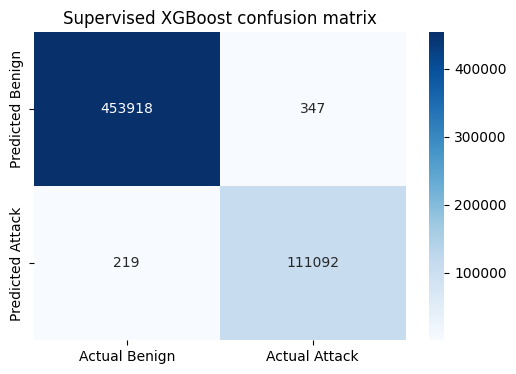

In [5]:
print('\n Final Evaluation')

# asking the model to predict the test set
predictions = xgb_model.predict(X_test_scaled)

print('Classification Report\n')

print(classification_report(y_test, predictions, target_names=['Benign (0)', 'Attack (1)'], digits=4))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues', xticklabels=['Actual Benign', 'Actual Attack'], yticklabels=['Predicted Benign', 'Predicted Attack'])

plt.title('Supervised XGBoost confusion matrix')
plt.show()


In [6]:
import joblib
joblib.dump(xgb_model, '/content/drive/MyDrive/xgboost_stage1.pkl')


['/content/drive/MyDrive/xgboost_stage1.pkl']